# Photometry of M16
## Importing Modules and Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
import astropy.units as u
import urllib.request
import os
import gzip
import shutil
from astropy.io import fits


## Downloading FITS Image of M16

In [2]:
from astropy.utils.data import download_file

m16_url = "https://mast.stsci.edu/api/v0.1/Download/file/?uri=mast:HST/product/ick909040_drz.fits"
m16_file = download_file(m16_url, cache = True)
m16_file 
#"https://opencomputinglab.github.io/SubjectMatterNotebooks/astronomy/fits-images.html"

'C:\\Users\\mya\\.astropy\\cache\\download\\url\\715233a8f11bfd011439fab978a69403\\contents'

## Backup Code

In [3]:
m16_hdu_list = fits.open(m16_file)
if 'm16.fits' not in os.listdir():
    m16_hdu_list.writeto('m16.fits')

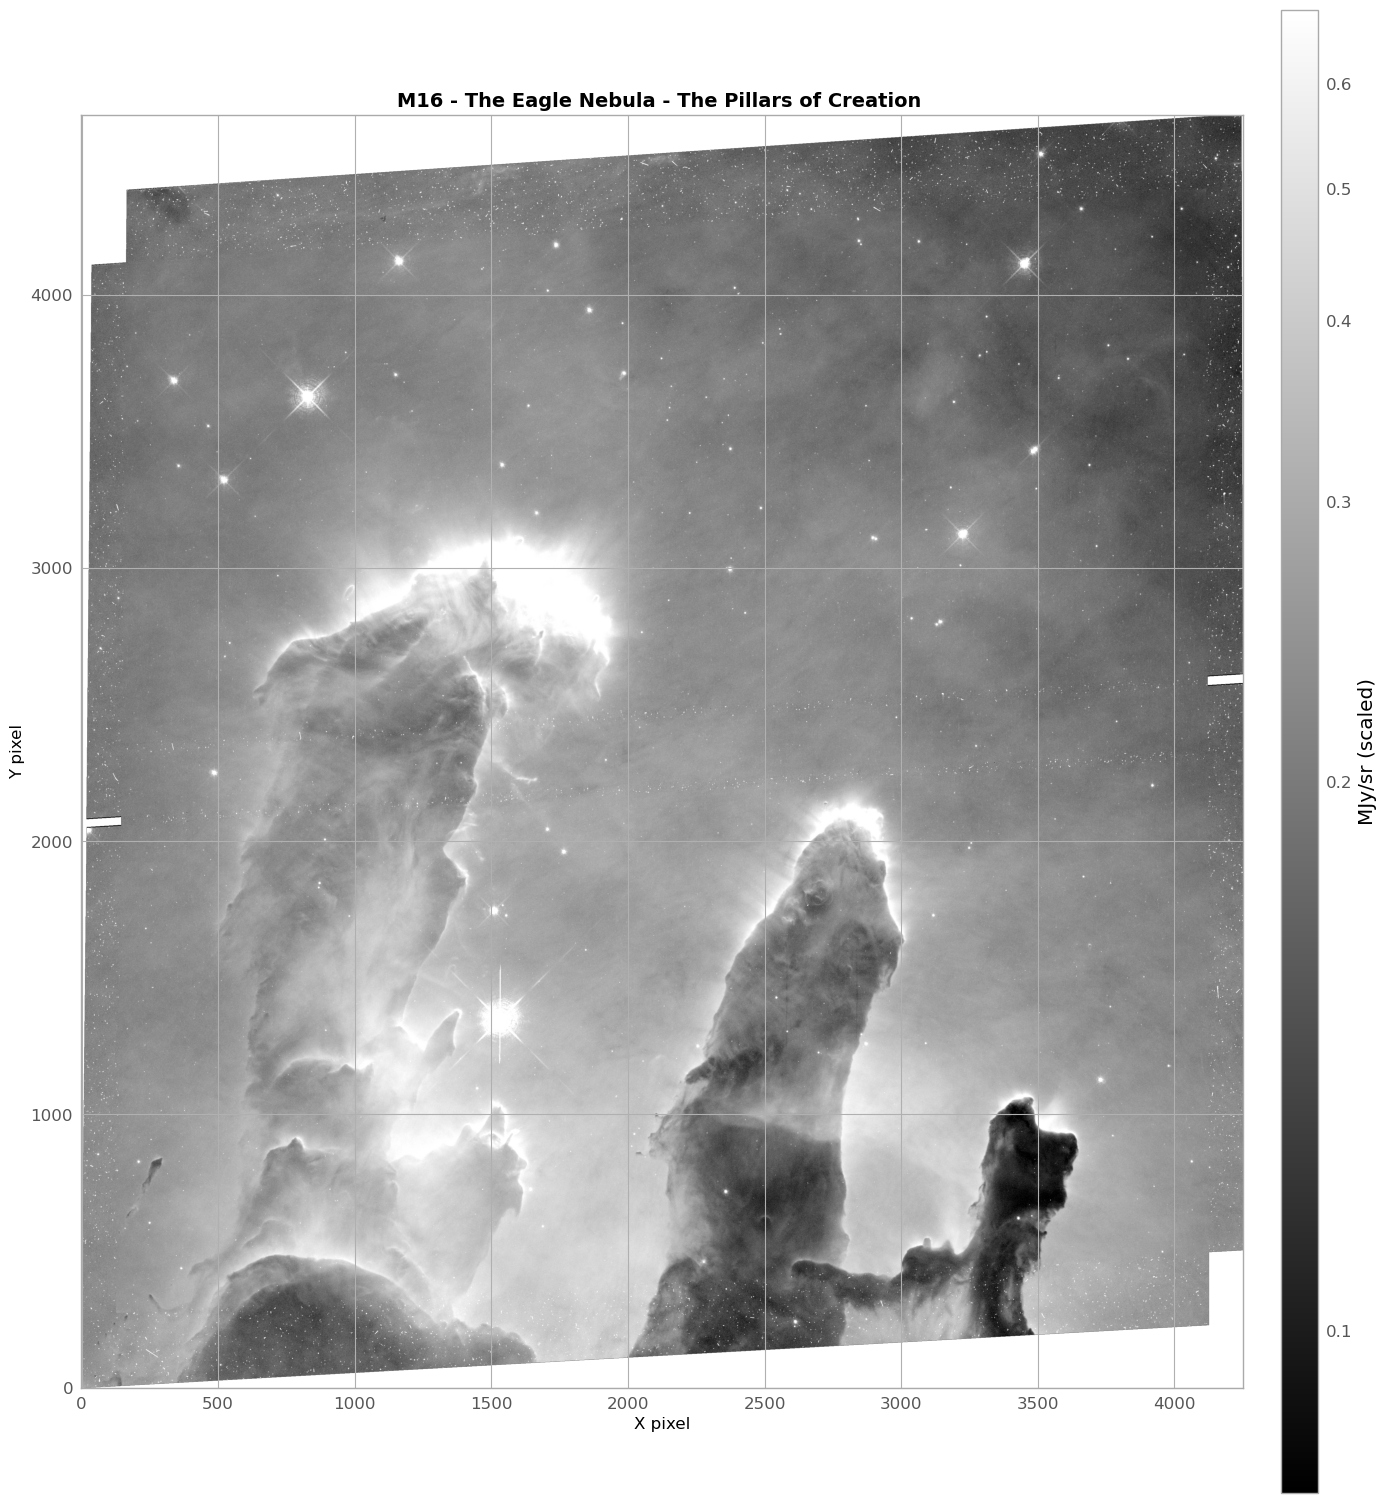

In [5]:
#Nice styling
from astropy.visualization import astropy_mpl_style
plt.style.use(astropy_mpl_style)

m16_data = fits.getdata('m16.fits')

#Display the image
#plt.imshow(image_data, cmap='gray')
#plt.colorbar();
#Lecture 14
if os.path.exists(m16_file) and m16_data is not None:
    from astropy.visualization import ZScaleInterval, AsinhStretch, ImageNormalize
    
    # Combine interval (ZScale finds optimal min/max) with stretch (AsinhStretch compresses dynamic range)
    norm = ImageNormalize(m16_data, 
                          interval=ZScaleInterval(),
                          stretch=AsinhStretch())
    
    # Calculate figure size maintaining aspect ratio
    aspect_ratio = m16_data.shape[0] / m16_data.shape[1]
    fig_width = 14
    fig_height = fig_width * aspect_ratio
    
    plt.figure(figsize=(fig_width, fig_height))
    
    # origin='lower' puts (0,0) at bottom-left (astronomical convention)
    plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
    plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
    plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
              fontsize=14, fontweight='bold')
    plt.xlabel('X pixel', fontsize=12)
    plt.ylabel('Y pixel', fontsize=12)
    plt.tight_layout()
    plt.show()
elif os.path.exists(m16_file):
    print("Skipping visualization - no image data loaded")

In [4]:
from astropy.stats import sigma_clipped_stats 
import photutils
from photutils.detection import DAOStarFinder
mean,median,std=sigma_clipped_stats(m16_data, sigma=3.0)
print(mean,median,std)

daofind=DAOStarFinder(fwhm=3.0,threshold=5*std)
# find sources
sources=daofind(m16_data-median)
sources

NameError: name 'm16_data' is not defined

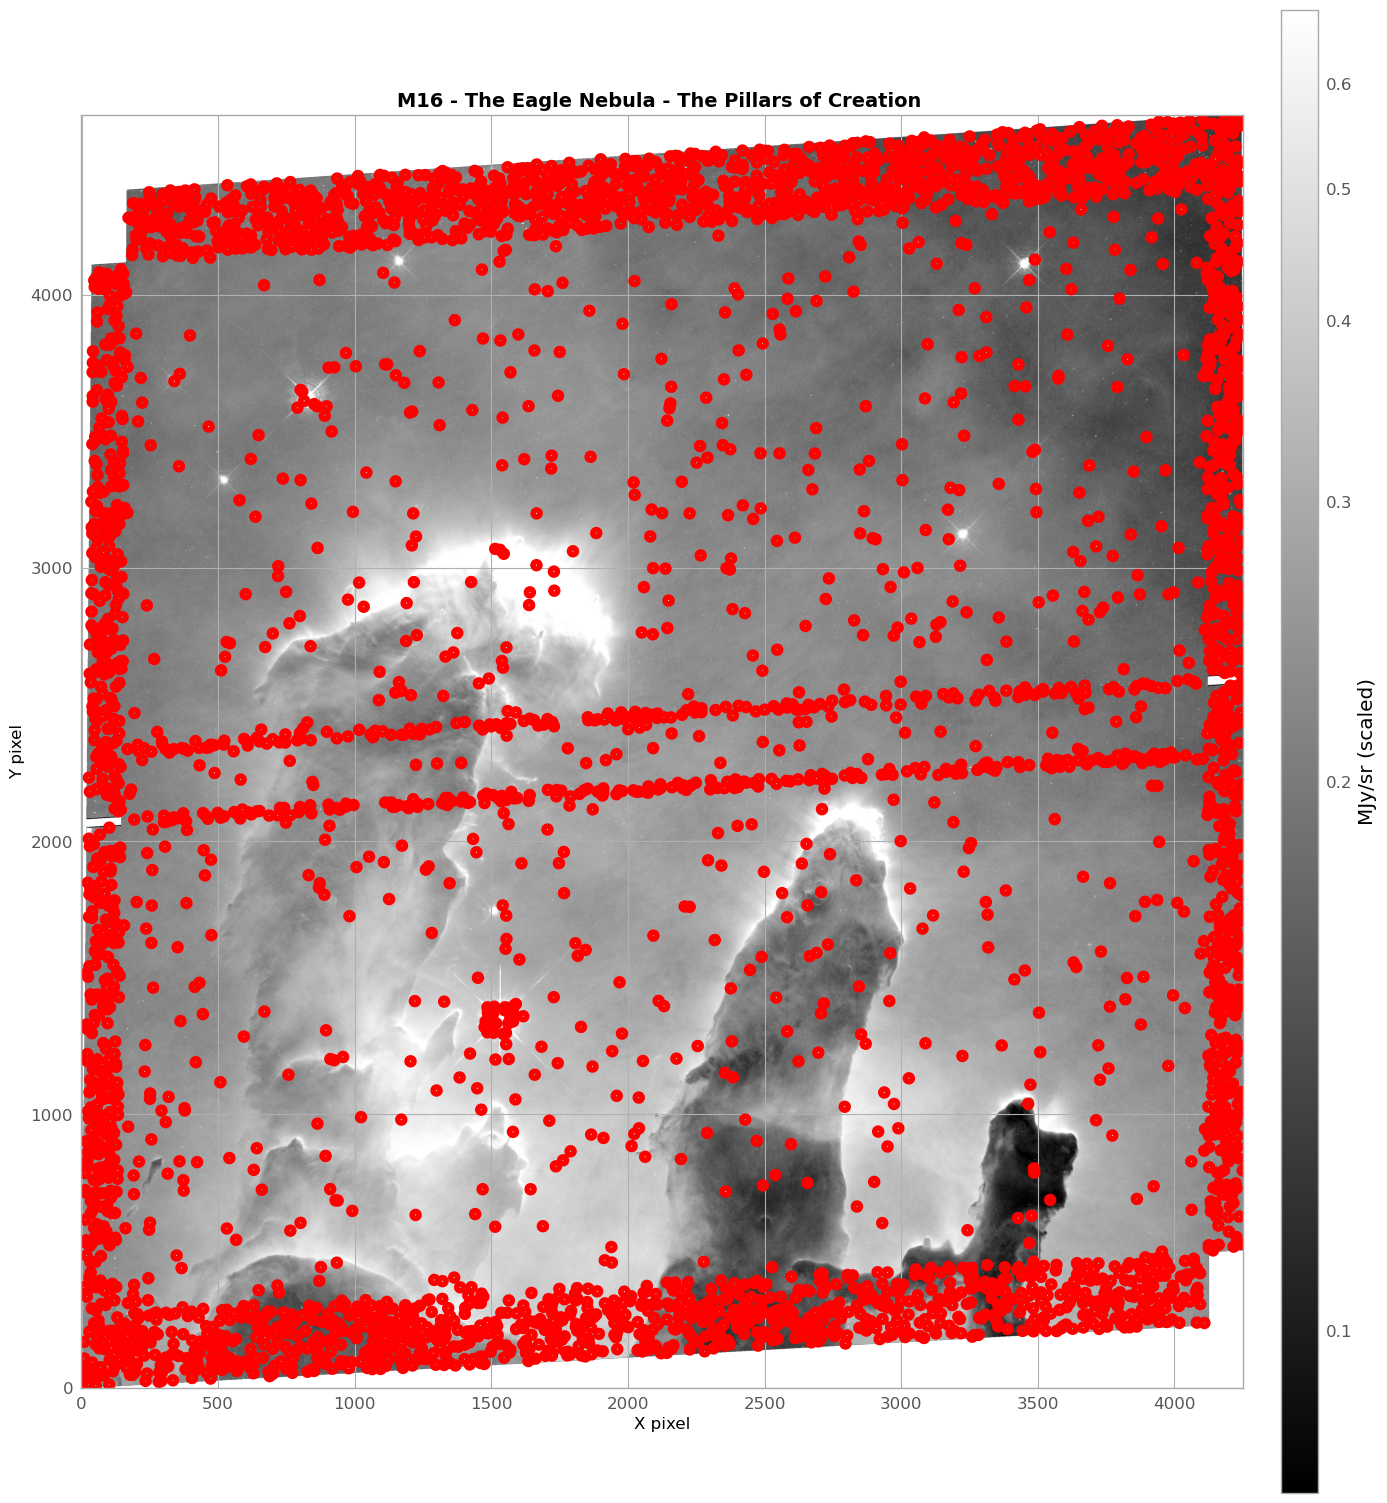

In [ ]:
from photutils.aperture import CircularAperture #code from DESI ASTRO 
positions = np.transpose((sources['xcentroid'],sources['ycentroid']))
plt.figure(figsize=(fig_width, fig_height))
apertures=CircularAperture(positions,r=10)
apertures.plot(color='red',lw=5)

plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
            fontsize=14, fontweight='bold')
plt.xlabel('X pixel', fontsize=12)
plt.ylabel('Y pixel', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
def star_cutout(x,y,position):
    pixels=15
    size=(pixels, pixels)
    cutout=Cutout2D(m16_data.data, position, size)
    minim=np.nanpercentile(cutout.data, 50)
    maxim=np.nanpercentile(cutout.data, 99.9)
    plt.imshow(cutout.data, origin=origin_pos, cmap=cmap, vmin=minim, vmax=maxim, norm='log')
    plt.show()

## Class Implementation Test

In [8]:
import numpy as np
from scipy.optimize import curve_fit

class ClusterAnalyzer:
    """
    A class to perform PSF photometry on an astronomical image 
    of an open cluster.
    """
    
    def __init__(self, m16_file):
        """Initialize the object by loading the data."""
        self.m16_hdu_list = fits.open(m16_file)
        if 'm16.fits' not in os.listdir():
            m16_hdu_list.writeto('m16.fits')
        
        self.stars_found = [] # To store (x, y) coordinates
        self.photometry_results = [] # To store fitted (flux, x, y)
        
    def show_image(self, title="Open Cluster Field"):
        """Utility method to visualize the data."""
        if os.path.exists(self.m16_file) and self.m16_data is not None:
            from astropy.visualization import ZScaleInterval, AsinhStretch, ImageNormalize
    
    # Combine interval (ZScale finds optimal min/max) with stretch (AsinhStretch compresses dynamic range)
            norm = ImageNormalize(self.m16_data, 
                          interval=ZScaleInterval(),
                          stretch=AsinhStretch())
    
    # Calculate figure size maintaining aspect ratio
            aspect_ratio = self.m16_data.shape[0] / self.m16_data.shape[1]
            fig_width = 14
            fig_height = fig_width * aspect_ratio
    
            plt.figure(figsize=(fig_width, fig_height))
    
    # origin='lower' puts (0,0) at bottom-left (astronomical convention)
            plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
            plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
            plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
              fontsize=14, fontweight='bold')
            plt.xlabel('X pixel', fontsize=12)
            plt.ylabel('Y pixel', fontsize=12)
            plt.tight_layout()
            plt.show()
        
        elif os.path.exists(m16_file):
            print("Skipping visualization - no image data loaded")
    
    @staticmethod
    def gaussian_2d(coords, amplitude, xo, yo, sigma):
        """
        A static method for the PSF model. 
        Note: The @staticmethod decorator is used to define a method inside a 
        class that does not depend on a specific instance's data or the class itself.
        """
        x, y = coords
        g = amplitude * np.exp(-((x-xo)**2 + (y-yo)**2) / (2*sigma**2))
        return g.ravel()

    def fit_star_psf(self, x_guess, y_guess, box_size=10):
        """
        Extracts a small sub-region around a guess and fits a 2D Gaussian.
        """
        # 1. Crop a small box around the star
        sub_image = self.m16_data[y_guess-box_size:y_guess+box_size, 
                                    x_guess-box_size:x_guess+box_size]
        
        # 2. Create a coordinate grid for the fit
        yp, xp = np.indices(sub_image.shape)
        
        # 3. Perform the fit
        initial_guess = (np.max(sub_image), box_size, box_size, 2.0)
        try:
            popt, _ = curve_fit(self.gaussian_2d, (xp, yp), sub_image.ravel(), p0=initial_guess)
            
            # Store results: [Flux (Amplitude), Global X, Global Y, Width]
            res = [popt[0], popt[1] + (x_guess-box_size), popt[2] + (y_guess-box_size)]
            self.photometry_results.append(res)
            return res
        except:
            print(f"Fit failed for star at {x_guess}, {y_guess}")
            return None


In [ ]:
from astropy.stats import sigma_clipped_stats 
import photutils
from photutils.detection import DAOStarFinder
mean,median,std=sigma_clipped_stats(m16_data, sigma=3.0)
print(mean,median,std)

daofind=DAOStarFinder(fwhm=3.0,threshold=5*std)
# find sources
sources=daofind(m16_data-median)
sources

In [ ]:
from photutils.aperture import CircularAperture #code from DESI ASTRO 
positions = np.transpose((sources['xcentroid'],sources['ycentroid']))
plt.figure(figsize=(fig_width, fig_height))
apertures=CircularAperture(positions,r=10)
apertures.plot(color='red',lw=5)

plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
            fontsize=14, fontweight='bold')
plt.xlabel('X pixel', fontsize=12)
plt.ylabel('Y pixel', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
x=1550
y=400
position=(x,y)
star_1=star_cutout(x,y,position)